In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
# Implements linear models using Stochastic Gradient Descent, While LogisticRegression exists in sklearn, 
# SGD Classifier is a more powerful version that uses Stochastic Gradient Descent. 
# It's necessary because it’s the "brain" that will learn the patterns in your data.
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
# These evaluate your model. They help you understand how well your model is performing and where it might be making mistakes.
from sklearn.metrics import (
    log_loss,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
# Load data
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [3]:
# Binary classification (same as your mask)
mask = y < 2
X = X[mask]
y = y[mask]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [5]:
# Model (logistic regression via SGD)
# loss="log_loss" tells the model to use logistic regression, It tells SGD to use:
# Log Loss (Cross Entropy)
# That makes this behave exactly like Logistic Regression.
# learning_rate="constant" means we want a fixed learning rate, 
# eta0=0.01 sets that learning rate to 0.01, and 
# random_state=0 ensures reproducibility.

model = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=0.01, random_state=0)
epochs = 100
train_losses = []
test_losses = []

In [6]:
classes = np.unique(y_train)
print("Classes:", classes)

Classes: [0 1]


In [7]:
# SGD in sklearn doesn’t automatically use epochs unless you manually loop and call partial_fit.
for epoch in range(epochs):
    model.partial_fit(X_train, y_train, classes=classes)

    train_probs = model.predict_proba(X_train)
    test_probs = model.predict_proba(X_test)

    train_losses.append(log_loss(y_train, train_probs))
    test_losses.append(log_loss(y_test, test_probs))


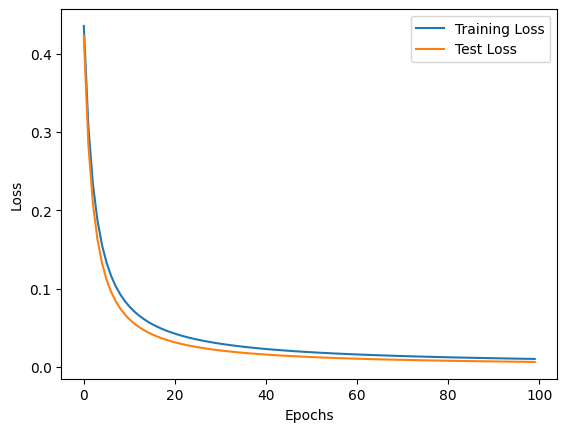

In [8]:
# Plot loss
plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [9]:
# Predictions
y_pred = model.predict(X_test)

# ---- Metrics ----
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nConfusion Matrix:\n", cm)
print("\nAccuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred))


Confusion Matrix:
 [[12  0]
 [ 0  8]]

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Detailed Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

